In [1]:
from data_importny import import_flight_data
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
data_dir = '/Users/anna-ida/Desktop/Applied-Machine-Learning/Final_project_data/data/ML_data/NBI/FDM data'
data_dir = 

df = import_flight_data(data_dir=data_dir,limit=1, recursive=True)


In [3]:
COLUMN_MAP = {
    # time
    "Year": "year",
    "QAR YEAR": "year",
    "Date: Year (Derived)": "year",

    "MONTH": "month",
    "QAR MONTH": "month",
    "Date (month)": "month",

    "DAY": "day",
    "QAR DAY": "day",
    "Date (day)": "day",

    "GMT - Hours (BCD)": "hour",
    "QAR HOUR": "hour",
    "UTC Hours": "hour",

    "GMT - Minutes (BCD)": "minute",
    "QAR MINUTE": "minute",
    "UTC Minutes": "minute",

    "GMT Seconds": "second",
    "QAR SECOND": "second",
    "UTC Seconds": "second",

    # altitude
    "Radio Altitude": "radio_altitude",
    "Radio Height 1": "radio_altitude",

    # vertical acceleration
    "Vertical Acceleration": "vert_acc",
    "Normal acceleration": "vert_acc",
}

In [4]:
N_arrivals = 1

arrival_data = import_flight_data(data_dir=data_dir, limit=N_arrivals, add_source_file=True, usecols=['Time (secs)','MONTH', 'DAY', 'Year', 'GMT - Hours (BCD)', 'GMT - Minutes (BCD)', 'GMT Seconds', 'Vertical Acceleration', 'Radio Altitude'])

arrival_data.columns.tolist()

['year',
 'month',
 'day',
 'hour',
 'minute',
 'second',
 'vert_acc',
 'radio_altitude',
 'source_file']

In [5]:
def extract_wind_data(flight_df, offset=10): 
    """
    Extracts wind data from the TWI dataset for a given flight, based on the landing time and an offset for the recording start time.
    Args:
        flight_df (pd.DataFrame): A DataFrame containing data for one flight, including landing time information.
        offset (int): The number of minutes before the landing time to start recording wind data. Default is 10 minutes.
    Returns:
        pd.DataFrame: A DataFrame containing the wind data for the specified time range.
    """

    first = flight_df.iloc[0]

    month = first['month'].astype(int)
    day = first['day'].astype(int)
    if day < 10:
        day_string = '0'+str(day)
    else:
        day_string = str(day)

    year = first['year'].astype(int)
    start_h = first['hour'].astype(int)
    start_m = first['minute'].astype(int)
    start_s = first['second'].astype(int)
    
    start_of_landing_time = pd.Timestamp(year=year,month=month,day=day,hour=start_h,minute=start_m,second=start_s)

    start_of_recording_time = start_of_landing_time - pd.Timedelta(minutes=offset)
    
    if start_of_recording_time.day != start_of_landing_time.day:
        raise ValueError("Start of recording time is on a different day than the landing time. Please adjust the offset or check the flight data.")
    
    date_string = str(year)+'-'+str(month)+'-'+day_string
    file_string = 'TWI-'+date_string+'_UTC_log.csv'

    wind_df = pd.read_csv('/Users/anna-ida/Desktop/Applied-Machine-Learning/Final_project_data/data/ML_data/TWI_data/'+file_string, sep=';')

    wind_df['DateTime'] = pd.to_datetime(wind_df['DateTime'], format='%Y-%m-%d %H:%M:%S')

    mask_time = (wind_df['DateTime'] >= start_of_recording_time) & (wind_df['DateTime'] <= start_of_landing_time)

    wind_df = wind_df.loc[mask_time].reset_index(drop=True)
    wind_df['source_file'] = first['source_file']
    return wind_df

extract_wind_data(arrival_data)

,DateTime,PcTime,ArrRwy04,ArrRwy22,DepRwy22,DepRwy04,ArrRwy04DepRwy22,ArrRwy22DepRwy04,W04.VectorMeanWindSpeed,W04.VectorMeanWindDirection,...,W22.ScalarMaxWindSpeed,W22.ScalarMaxWindAtDirection,W22.ScalarMeanWindSpeed,W22.ScalarWindSpeedDeviation,W22.ScalarMeanWindDirection,W22.ScalarWindDirectionDeviation,W22.LastWindSpeed,W22.LastWindDirection,W22.OkPct,source_file
0,2024-11-28 12:04:29,2024-11-28 10:04:30,2,2,2,2,0,0,3.446184,65.886639,...,9.1,36,7.655263,0.986940,42.496327,6.344822,7.5,38,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...
1,2024-11-28 12:04:35,2024-11-28 10:04:35,2,2,2,2,0,0,3.477918,66.050344,...,9.1,36,7.613158,1.000045,42.311610,6.212914,6.7,45,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...
2,2024-11-28 12:04:38,2024-11-28 10:04:40,2,2,2,2,0,0,3.500163,66.170129,...,9.1,36,7.584211,1.027139,42.152913,6.245114,6.1,38,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...
3,2024-11-28 12:04:44,2024-11-28 10:04:45,2,2,2,2,0,0,3.582905,66.839029,...,9.1,36,7.544737,1.070587,41.626817,5.860641,6.2,41,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...
4,2024-11-28 12:04:50,2024-11-28 10:04:50,2,2,2,2,0,0,3.604055,67.683592,...,9.1,36,7.636842,0.996948,41.207986,5.333008,7.7,44,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-11-28 12:14:05,2024-11-28 10:14:05,2,2,2,2,0,0,5.671798,57.058410,...,9.8,48,7.655263,0.677339,44.739281,4.091417,9.5,42,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...
116,2024-11-28 12:14:05,2024-11-28 10:14:10,2,2,2,2,0,0,5.671798,57.058410,...,9.8,48,7.655263,0.677339,44.739281,4.091417,9.5,42,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...
117,2024-11-28 12:14:14,2024-11-28 10:14:15,2,2,2,2,0,0,5.650666,58.035348,...,9.8,48,7.697368,0.706171,44.844736,4.096976,8.5,48,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...
118,2024-11-28 12:14:20,2024-11-28 10:14:20,2,2,2,2,0,0,5.641713,58.698637,...,9.8,48,7.702632,0.704305,44.923497,4.206698,7.4,50,95.0,/Users/anna-ida/Desktop/Applied-Machine-Learni...


In [6]:
N_arrivals = 100

arrival_data = import_flight_data(data_dir=data_dir,
    limit=N_arrivals, add_source_file=True, usecols=['month', 'day', 'year', 'hour', 'minute', 'second', 'vert_acc', 'radio_altitude'])


full_wind_data = []
idx = 0

for flight_id, flight_df in arrival_data.groupby('source_file'):
    idx +=1
    print(f"Processing flight: {idx}/{len(arrival_data.groupby('source_file'))}")
    try:
        wind_df = extract_wind_data(flight_df)
        wind_df['source_file'] = flight_id
        full_wind_data.append(wind_df)

    except ValueError as e:
        print(f"Error processing flight {flight_id}: {e}")
full_wind_data = pd.concat(full_wind_data, ignore_index=True)

Processing flight: 1/92
Processing flight: 2/92
Processing flight: 3/92
Processing flight: 4/92
Processing flight: 5/92
Processing flight: 6/92
Processing flight: 7/92
Processing flight: 8/92
Processing flight: 9/92
Processing flight: 10/92
Processing flight: 11/92
Processing flight: 12/92
Processing flight: 13/92
Processing flight: 14/92
Processing flight: 15/92
Processing flight: 16/92
Processing flight: 17/92
Processing flight: 18/92
Processing flight: 19/92
Processing flight: 20/92
Processing flight: 21/92
Processing flight: 22/92
Processing flight: 23/92
Processing flight: 24/92
Processing flight: 25/92
Processing flight: 26/92
Processing flight: 27/92
Processing flight: 28/92
Processing flight: 29/92
Processing flight: 30/92
Processing flight: 31/92
Processing flight: 32/92
Processing flight: 33/92
Processing flight: 34/92
Processing flight: 35/92
Processing flight: 36/92
Processing flight: 37/92
Processing flight: 38/92
Processing flight: 39/92
Processing flight: 40/92
Processin

In [7]:
for idx, file in full_wind_data.groupby('source_file'):
    print(file['DateTime'].min(), file['DateTime'].max(), file['source_file'].iloc[0])

2024-11-28 12:04:29 2024-11-28 12:14:23 /Users/anna-ida/Desktop/Applied-Machine-Learning/Final_project_data/data/ML_data/NBI/FDM data/Arrivals/Nuuk Arrival_ 207724_OY-GRH_28_11_24_16_12.csv
2024-11-28 11:32:50 2024-11-28 11:42:44 /Users/anna-ida/Desktop/Applied-Machine-Learning/Final_project_data/data/ML_data/NBI/FDM data/Arrivals/Nuuk Arrival_ 207725_OY-GRP_28_11_24_43_11.csv
2024-11-28 14:29:35 2024-11-28 14:39:29 /Users/anna-ida/Desktop/Applied-Machine-Learning/Final_project_data/data/ML_data/NBI/FDM data/Arrivals/Nuuk Arrival_ 207731_OY-GRG_28_11_24_41_14.csv
2024-11-28 15:19:05 2024-11-28 15:28:59 /Users/anna-ida/Desktop/Applied-Machine-Learning/Final_project_data/data/ML_data/NBI/FDM data/Arrivals/Nuuk Arrival_ 207732_OY-GRK_28_11_24_31_15.csv
2024-11-28 15:44:04 2024-11-28 15:53:59 /Users/anna-ida/Desktop/Applied-Machine-Learning/Final_project_data/data/ML_data/NBI/FDM data/Arrivals/Nuuk Arrival_ 207734_OY-GRH_28_11_24_56_15.csv
2024-11-28 16:48:34 2024-11-28 16:58:29 /Users/ann

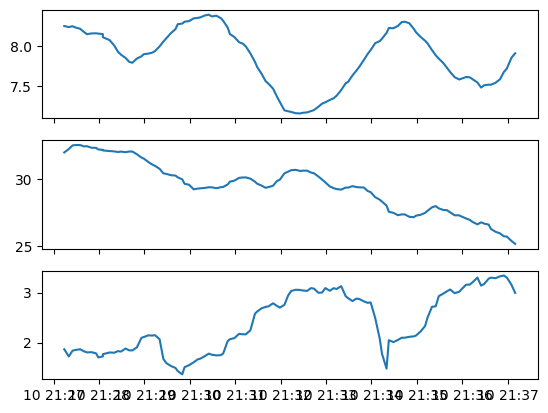

In [8]:
fig, ax = plt.subplots(3,1,sharex=True)
ax[0].plot(wind_df["DateTime"],wind_df["W04.VectorMeanWindSpeed"])
ax[1].plot(wind_df["DateTime"],wind_df["W04.VectorMeanWindDirection"])
ax[2].plot(wind_df["DateTime"],wind_df["W04.ScalarWindDirectionDeviation"])

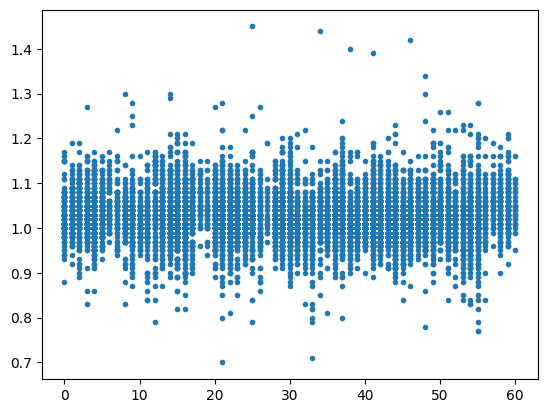

In [9]:
plt.plot(arrival_data["minute"], arrival_data["vert_acc"], '.',label="Arrivals")


In [10]:
all_wind_data = pd.read_csv("/Users/anna-ida/Desktop/Applied-Machine-Learning/FinalProject/AppML-Final-Project/All_wind_data.csv") 
all_wind_data

,DateTime,PcTime,ArrRwy04,ArrRwy22,DepRwy22,DepRwy04,ArrRwy04DepRwy22,ArrRwy22DepRwy04,W04.VectorMeanWindSpeed,W04.VectorMeanWindDirection,...,W22.ScalarMaxWindSpeed,W22.ScalarMaxWindAtDirection,W22.ScalarMeanWindSpeed,W22.ScalarWindSpeedDeviation,W22.ScalarMeanWindDirection,W22.ScalarWindDirectionDeviation,W22.LastWindSpeed,W22.LastWindDirection,W22.OkPct,source_file
0,2024-11-28 12:04:29,2024-11-28 10:04:30,2,2,2,2,0,0,3.446184,65.886639,...,9.1,36,7.655263,0.986940,42.496327,6.344822,7.5,38,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...
1,2024-11-28 12:04:35,2024-11-28 10:04:35,2,2,2,2,0,0,3.477918,66.050344,...,9.1,36,7.613158,1.000045,42.311610,6.212914,6.7,45,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...
2,2024-11-28 12:04:38,2024-11-28 10:04:40,2,2,2,2,0,0,3.500163,66.170129,...,9.1,36,7.584211,1.027139,42.152913,6.245114,6.1,38,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...
3,2024-11-28 12:04:44,2024-11-28 10:04:45,2,2,2,2,0,0,3.582905,66.839029,...,9.1,36,7.544737,1.070587,41.626817,5.860641,6.2,41,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...
4,2024-11-28 12:04:50,2024-11-28 10:04:50,2,2,2,2,0,0,3.604055,67.683592,...,9.1,36,7.636842,0.996948,41.207986,5.333008,7.7,44,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343281,2024-11-28 09:41:59,2024-11-28 07:42:00,2,2,2,2,0,0,2.225123,110.496882,...,7.2,43,5.768421,0.717857,49.498953,5.381400,5.3,51,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...
343282,2024-11-28 09:42:04,2024-11-28 07:42:05,2,2,2,2,0,0,2.162421,112.648615,...,7.0,45,5.673684,0.664785,50.105450,5.202855,5.3,53,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...
343283,2024-11-28 09:42:06,2024-11-28 07:42:10,2,2,2,2,0,0,2.138135,113.644955,...,7.0,45,5.673684,0.664785,50.105450,5.202855,5.3,53,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...
343284,2024-11-28 09:42:15,2024-11-28 07:42:15,2,2,2,2,0,0,2.077918,116.164681,...,7.0,45,5.623684,0.616627,50.501166,5.044398,6.2,51,95.0,/Users/rasmus/Desktop/Fysik/AppliedML2026/Fina...


In [11]:
sum_V_MEAN_WS = all_wind_data.groupby('source_file').agg({
    'W04.VectorMeanWindSpeed': ['mean', 'max', 'std','median']})
#print(summary_df)

sum_V_MEAN_WD = all_wind_data.groupby('source_file').agg({
    'W04.VectorMeanWindDirection': ['mean', 'max', 'std','median']})

sum_S_MAX_WS = all_wind_data.groupby('source_file').agg({
    'W22.ScalarMaxWindSpeed': ['mean', 'max', 'std','median']})

sum_S_MAX_WD = all_wind_data.groupby('source_file').agg({
    'W22.ScalarMaxWindAtDirection': ['mean', 'max', 'std','median']})

sum_S_MEAN_WS = all_wind_data.groupby('source_file').agg({
    'W22.ScalarMeanWindSpeed': ['mean', 'max', 'std','median']})

sum_S_WSD = all_wind_data.groupby('source_file').agg({
    'W22.ScalarWindSpeedDeviation': ['mean', 'max', 'std','median']})

sum_MEAN_WD = all_wind_data.groupby('source_file').agg({
    'W22.ScalarMeanWindDirection': ['mean', 'max', 'std','median']})

sum_S_WDD = all_wind_data.groupby('source_file').agg({
    'W22.ScalarWindDirectionDeviation': ['mean', 'max', 'std','median']})

sum_Last_WS = all_wind_data.groupby('source_file').agg({
    'W22.LastWindSpeed': ['mean', 'max', 'std','median']})

sum_Last_WD = all_wind_data.groupby('source_file').agg({
    'W22.LastWindDirection': ['mean', 'max', 'std','median']})




In [ ]:
columns_to_analyze = [
    'W04.VectorMeanWindSpeed',
    'W04.VectorMeanWindDirection',
    'W22.ScalarMaxWindSpeed',
    'W22.ScalarMaxWindAtDirection',
    'W22.ScalarMeanWindSpeed',
    'W22.ScalarWindSpeedDeviation',
    'W22.ScalarMeanWindDirection',
    'W22.ScalarWindDirectionDeviation',
    'W22.LastWindSpeed',
    'W22.LastWindDirection']

statistics = ['mean', 'max', 'std', 'median']

summary_df = (
    all_wind_data
    .groupby('source_file')[columns_to_analyze]
    .agg(statistics))

',W04.VectorMeanWindSpeed,W04.VectorMeanWindSpeed,W04.VectorMeanWindSpeed,W04.VectorMeanWindSpeed,W04.VectorMeanWindDirection,W04.VectorMeanWindDirection,W04.VectorMeanWindDirection,W04.VectorMeanWindDirection,W22.ScalarMaxWindSpeed,W22.ScalarMaxWindSpeed,W22.ScalarMaxWindSpeed,W22.ScalarMaxWindSpeed,W22.ScalarMaxWindAtDirection,W22.ScalarMaxWindAtDirection,W22.ScalarMaxWindAtDirection,W22.ScalarMaxWindAtDirection,W22.ScalarMeanWindSpeed,W22.ScalarMeanWindSpeed,W22.ScalarMeanWindSpeed,W22.ScalarMeanWindSpeed,W22.ScalarWindSpeedDeviation,W22.ScalarWindSpeedDeviation,W22.ScalarWindSpeedDeviation,W22.ScalarWindSpeedDeviation,W22.ScalarMeanWindDirection,W22.ScalarMeanWindDirection,W22.ScalarMeanWindDirection,W22.ScalarMeanWindDirection,W22.ScalarWindDirectionDeviation,W22.ScalarWindDirectionDeviation,W22.ScalarWindDirectionDeviation,W22.ScalarWindDirectionDeviation,W22.LastWindSpeed,W22.LastWindSpeed,W22.LastWindSpeed,W22.LastWindSpeed,W22.LastWindDirection,W22.LastWindDirection,W22.LastWi

In [ ]:
summary_df = (
    all_wind_data
    .groupby('source_file')[columns_to_analyze]
    .agg(statistics))

# Add this
summary_df.columns = [
    f"{col}_{stat}".replace('.', '_')
    for col, stat in summary_df.columns]

summary_df.to_csv("summary.csv")
print(len(summary_df.columns))

40


In [14]:
from pathlib import Path
output_path = Path.cwd().parent / 'x_data.csv'
summary_df.to_csv(output_path, index=False)

In [15]:
flight_mean = arrival_data.groupby('source_file')['vert_acc'].mean()


plt.figure(figsize=(30,20))
plt.plot(flight_max.index, flight_max.values)
plt.show()

NameError: name 'flight_max' is not defined

<Figure size 3000x2000 with 0 Axes>

In [ ]:
print(flight_mean.max())

1.0744086021505377
